## Bootstrap

C:\Users\USER\AppData\Local\Temp\ipykernel_23832\3617241097.py:26: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=START, end=END)[0].copy()
C:\Users\USER\AppData\Local\Temp\ipykernel_23832\3617241097.py:26: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=START, end=END)[0].copy()


===== Rolling MV Optimization (No forecast) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=True
                           AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)        0.110616  0.155668      0.710589 -0.503117
EW Factors                  0.041244  0.081791      0.504267 -0.255091
MV-Opt (No forecast, 60M)   0.073937  0.125657      0.588403 -0.266962


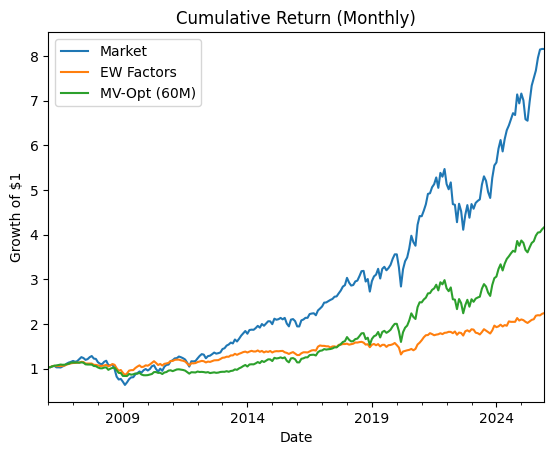

<Figure size 640x480 with 0 Axes>

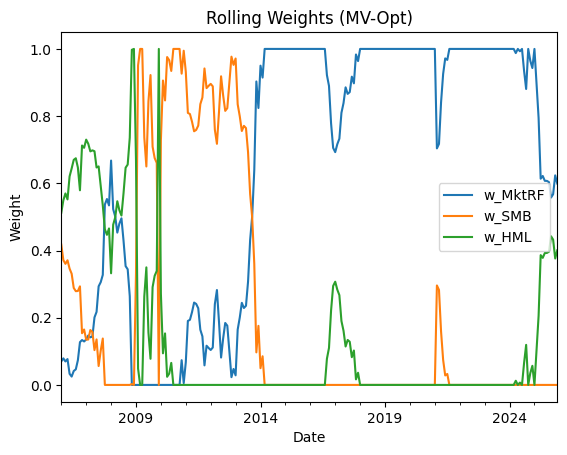


===== Rolling MV Optimization (AR1 forecast) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=True
                            AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)         0.110616  0.155668      0.710589 -0.503117
EW Factors                   0.041244  0.081791      0.504267 -0.255091
MV-Opt (No forecast, 60M)    0.073937  0.125657      0.588403 -0.266962
MV-Opt (AR1 forecast, 60M)   0.086539  0.119771      0.722538 -0.206971


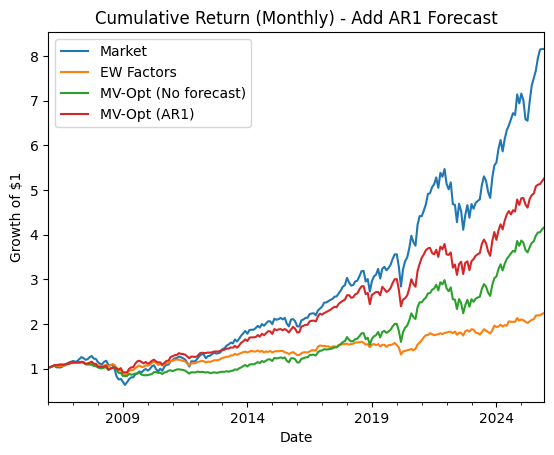

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Feb 12 16:36:18 2026

@author: jx2on
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader.data as web

# =========================
# 설정
# =========================
START = "2001-01-01"
END   = "2025-12-31"

WINDOW = 60          # 60개월 rolling window
GAMMA  = 5.0         # 위험회피계수(클수록 보수적)
LONG_ONLY = True     # True면 공매도(음수 비중) 금지

# =========================
# 1) FF3 (Monthly) 불러오기
# =========================
ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=START, end=END)[0].copy()

# 인덱스를 월말 날짜로
ff.index = pd.to_datetime(ff.index.astype(str)) + pd.offsets.MonthEnd(0)

# % -> 소수
ff = ff / 100.0
ff = ff.loc[(ff.index >= START) & (ff.index <= END)].dropna()

# 사용할 팩터 (초과수익 팩터 3개)
F = ff[["Mkt-RF", "SMB", "HML"]].copy()   # excess returns
RF = ff["RF"].copy()                     # risk-free

# =========================
# 2) 벤치마크/단순전략 (비교용)
# =========================
ret_mkt = ff["Mkt-RF"] + ff["RF"]
ret_ew  = (ff["Mkt-RF"] + ff["SMB"] + ff["HML"]) / 3.0 + ff["RF"]

# =========================
# 3) 평균-분산 최적화 함수
#    w* = (1/gamma) * Sigma^{-1} * mu
#    (초과수익 기준; 총수익은 RF + w·F)
# =========================
def mv_weights(mu: np.ndarray, cov: np.ndarray, gamma: float, long_only: bool) -> np.ndarray:
    # 수치 안정화: 공분산 행렬에 작은 값 더하기
    eps = 1e-6
    cov = cov + eps * np.eye(cov.shape[0])

    w = (1.0 / gamma) * np.linalg.solve(cov, mu)  # Sigma^{-1} mu

    if long_only:
        w = np.maximum(w, 0.0)  # 음수 제거

    # 너무 크거나 이상한 값 방지: 합이 0이면 균등
    s = w.sum()
    if s <= 1e-12:
        w = np.ones_like(w) / len(w)
    else:
        # "팩터 포트폴리오"를 100%로 정규화(합=1)
        w = w / s

    return w

# =========================
# 4) Rolling backtest
# =========================
dates = F.index
rets_opt = []
w_hist = []

for t in range(WINDOW, len(dates)):
    # 추정 구간: t-WINDOW ~ t-1
    train = F.iloc[t-WINDOW:t]
    mu = train.mean().values                # (3,)
    cov = train.cov().values                # (3,3)

    w = mv_weights(mu, cov, gamma=GAMMA, long_only=LONG_ONLY)
    w_hist.append(w)

    # 투자 구간: t (다음 달) 실현 수익률
    f_next = F.iloc[t].values               # (3,)
    r_next = float(RF.iloc[t] + np.dot(w, f_next))  # 총수익 = RF + w·(excess factors)
    rets_opt.append(r_next)

ret_opt = pd.Series(rets_opt, index=dates[WINDOW:], name="MV-Opt (No forecast, 60M)")

w_hist = pd.DataFrame(w_hist, index=dates[WINDOW:], columns=["w_MktRF", "w_SMB", "w_HML"])

# =========================
# 5) 성과지표
# =========================
def perf_stats(r: pd.Series, name: str):
    r = r.dropna()
    ann_return = float((1 + r).prod() ** (12 / len(r)) - 1)
    ann_vol    = float(r.std() * np.sqrt(12))
    sharpe     = ann_return / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = float(dd.min())

    return pd.Series(
        {"AnnReturn": ann_return, "AnnVol": ann_vol, "Sharpe(rf=0)": sharpe, "MDD": mdd},
        name=name
    )

stats = pd.concat([
    perf_stats(ret_mkt.loc[ret_opt.index], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[ret_opt.index],  "EW Factors"),
    perf_stats(ret_opt,                   "MV-Opt (No forecast, 60M)")
], axis=1).T

print("===== Rolling MV Optimization (No forecast) =====")
print(f"기간(최적화 백테스트): {ret_opt.index[0].date()} ~ {ret_opt.index[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}")
print(stats)

# =========================
# 6) 그래프: 누적수익률 + 가중치 변화
# =========================
cum_mkt = (1 + ret_mkt.loc[ret_opt.index]).cumprod()
cum_ew  = (1 + ret_ew.loc[ret_opt.index]).cumprod()
cum_opt = (1 + ret_opt).cumprod()

plt.figure()
cum_mkt.plot(label="Market")
cum_ew.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (60M)")
plt.title("Cumulative Return (Monthly)")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

plt.figure()
w_hist.plot()
plt.title("Rolling Weights (MV-Opt)")
plt.ylabel("Weight")
plt.show()

from statsmodels.tsa.ar_model import AutoReg

# =========================
# AR(1)로 다음 달 팩터 프리미엄(초과수익) 예측해서 mu 만들기
# mu_hat = [E(Mkt-RF_{t+1}), E(SMB_{t+1}), E(HML_{t+1})]
# =========================
def ar1_forecast_mu(train_df: pd.DataFrame) -> np.ndarray:
    mu_hat = []
    for col in train_df.columns:
        y = train_df[col].values

        # AR(1) 적합 (상수 포함)
        model = AutoReg(y, lags=1, trend="c", old_names=False).fit()

        # 1-step ahead forecast
        f = float(model.forecast(steps=1)[0])
        mu_hat.append(f)

    return np.array(mu_hat)

# =========================
# AR Forecast + MV Optimization Rolling Backtest
# =========================
rets_ar = []
w_ar_hist = []

for t in range(WINDOW, len(dates)):
    train = F.iloc[t-WINDOW:t]

    # 기대수익(μ)을 AR(1) 예측값으로 사용
    mu_hat = ar1_forecast_mu(train)

    # 공분산은 과거 60개월 샘플 공분산
    cov = train.cov().values

    w = mv_weights(mu_hat, cov, gamma=GAMMA, long_only=LONG_ONLY)
    w_ar_hist.append(w)

    f_next = F.iloc[t].values
    r_next = float(RF.iloc[t] + np.dot(w, f_next))
    rets_ar.append(r_next)

ret_ar = pd.Series(rets_ar, index=dates[WINDOW:], name="MV-Opt (AR1 forecast, 60M)")
w_ar_hist = pd.DataFrame(w_ar_hist, index=dates[WINDOW:], columns=["w_MktRF", "w_SMB", "w_HML"])

# =========================
# 비교표 업데이트 (Market / EW / No-forecast MV / AR MV)
# =========================
stats2 = pd.concat([
    perf_stats(ret_mkt.loc[ret_opt.index], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[ret_opt.index],  "EW Factors"),
    perf_stats(ret_opt,                   "MV-Opt (No forecast, 60M)"),
    perf_stats(ret_ar,                    "MV-Opt (AR1 forecast, 60M)")
], axis=1).T

print("\n===== Rolling MV Optimization (AR1 forecast) =====")
print(f"기간(최적화 백테스트): {ret_ar.index[0].date()} ~ {ret_ar.index[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}")
print(stats2)

# =========================
# 누적수익률 비교 그래프 (옵션)
# =========================
cum_ar = (1 + ret_ar).cumprod()

plt.figure()
cum_mkt.plot(label="Market")
cum_ew.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (No forecast)")
cum_ar.plot(label="MV-Opt (AR1)")
plt.title("Cumulative Return (Monthly) - Add AR1 Forecast")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()


In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from arch import arch_model
import matplotlib.pyplot as plt
import pandas_datareader.data as web

# =====================================================================
# 0. 데이터 준비 (강건성.ipynb 파일과 동일하게 파마-프렌치 5팩터 사용)
# =====================================================================
print("Fama-French 5 Factors 데이터를 준비합니다...")
ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2001-01-01", end="2025-12-31")[0].copy()
ff5.index = pd.to_datetime(ff5.index.astype(str)) + pd.offsets.MonthEnd(0)
ff5 = ff5 / 100.0
F = ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].dropna()

# 윈도우 사이즈 설정 (최근 60개월)
window_size = 60
y = F.iloc[-window_size:] 

# 데이터 길이 및 변수 개수
T = len(y)
K = y.shape[1] # 변수 개수 (5개)

iterations = 1000  # 부트스트랩 반복 횟수

# =====================================================================
# 1. 사용자님이 올려주신 원본 AR Bootstrap 함수 (factor_name 추가)
# =====================================================================
def bootstrap(garch_fit, resids, y, T, iterations, phi_hat, factor_name):
    boot_phis_null = []
    omega, alpha, beta = garch_fit.params['omega'], garch_fit.params['alpha[1]'], garch_fit.params['beta[1]']
    cond_vol = garch_fit.conditional_volatility
    std_resids = (resids / cond_vol).dropna().values
    
    model_h0 = sm.OLS(y, np.ones(T)).fit()
    c_h0 = model_h0.params.iloc[0]
    resids_h0 = model_h0.resid
    
    garch_h0 = arch_model(resids_h0, vol='Garch', p=1, q=1, rescale=False)
    garch_fit_h0 = garch_h0.fit(disp='off')
    omega_h0, alpha_h0, beta_h0 = garch_fit_h0.params['omega'], garch_fit_h0.params['alpha[1]'], garch_fit_h0.params['beta[1]']
    std_resids_h0 = (resids_h0 / garch_fit_h0.conditional_volatility).dropna().values
    
    for _ in range(iterations):
        sim_y = np.zeros(T)
        sim_sigma2 = np.zeros(T)
        sim_eps = np.zeros(T)       
        sim_sigma2[0] = np.var(resids_h0)
        sim_eps[0] = resids_h0.iloc[0]
        sim_y[0] = y.iloc[0]       
        random_z = np.random.choice(std_resids_h0, size=T, replace=True)
        for t in range(1, T):
            sim_sigma2[t] = omega_h0 + alpha_h0 * (sim_eps[t-1]**2) + beta_h0 * sim_sigma2[t-1]
            sim_eps[t] = np.sqrt(sim_sigma2[t]) * random_z[t]
            sim_y[t] = c_h0 + sim_eps[t]
            
        sim_X = sm.add_constant(pd.Series(sim_y).shift(1).dropna())
        sim_model = sm.OLS(sim_y[1:], sim_X).fit()
        boot_phis_null.append(sim_model.params.iloc[1])
        
    boot_phis_null = np.array(boot_phis_null)
    p_value = np.mean(np.abs(boot_phis_null) >= np.abs(phi_hat))
    
    fig = plt.figure(figsize=(8, 4))
    plt.hist(boot_phis_null, bins=50, color='lightgray', edgecolor='black')
    plt.axvline(phi_hat, color='red', linestyle='dashed', linewidth=2, label=f'Original $\phi$ ({phi_hat:.4f})')
    plt.axvline(-phi_hat, color='red', linestyle='dashed', linewidth=2)
    plt.title(f'AR(1) Bootstrap Null Distribution [{factor_name}] | P-value: {p_value:.4f}')
    plt.legend()
    plt.show()
    return boot_phis_null

# =====================================================================
# 2. VAR(1) Bootstrap 함수
# =====================================================================
def bootstrap_var(y, resids, T, K, iterations, phi_hat):
    c_h0 = y.mean(axis=0).values
    resids_h0 = (y - c_h0).values
    boot_phis_null = np.zeros((iterations, K, K))
    
    for i in range(iterations):
        sim_y = np.zeros((T, K))
        sim_y[0] = y.iloc[0].values
        
        # 5개 변수 잔차 묶음을 동시 리샘플링
        random_indices = np.random.choice(T, size=T, replace=True)
        sim_resids = resids_h0[random_indices]
        
        for t in range(1, T):
            sim_y[t] = c_h0 + sim_resids[t]
            
        sim_df = pd.DataFrame(sim_y, columns=y.columns)
        sim_model = VAR(sim_df)
        try:
            sim_results = sim_model.fit(1)
            boot_phis_null[i] = sim_results.coefs[0]
        except np.linalg.LinAlgError:
            continue
            
    # Mkt-RF가 Mkt-RF에 미치는 계수(5x5 행렬 중 [0,0])를 기준으로 시각화
    p_value = np.mean(np.abs(boot_phis_null[:, 0, 0]) >= np.abs(phi_hat[0, 0]))
    
    fig = plt.figure(figsize=(8, 4))
    plt.hist(boot_phis_null[:, 0, 0], bins=50, color='lightblue', edgecolor='black')
    plt.axvline(phi_hat[0, 0], color='blue', linestyle='dashed', linewidth=2, label=f'Original $\Phi_{{11}}$ ({phi_hat[0, 0]:.4f})')
    plt.axvline(-phi_hat[0, 0], color='blue', linestyle='dashed', linewidth=2)
    plt.title(f'VAR(1) Bootstrap Null Distribution [Mkt-RF -> Mkt-RF] | P-value: {p_value:.4f}')
    plt.legend()
    plt.show()
    return boot_phis_null

# =====================================================================
# 3. 실행 및 시각화 출력
# =====================================================================

print("\n========================================================")
print("1. 단변량 AR(1) 부트스트랩 결과 (5개 팩터 각각 실행)")
print("========================================================")
ar_results = {}
for col in y.columns:
    print(f"\n▶ 타겟 팩터: {col}")
    y_ar = y[col]
    
    # 모델 피팅
    X_ar = sm.add_constant(y_ar.shift(1).dropna())
    model_ar = sm.OLS(y_ar.iloc[1:], X_ar).fit()
    c_hat_ar, phi_hat_ar = model_ar.params.iloc[0], model_ar.params.iloc[1]
    resids_ar = model_ar.resid
    
    garch = arch_model(resids_ar, vol='Garch', p=1, q=1, rescale=False)
    garch_fit = garch.fit(disp='off')
    
    # 해당 팩터에 대해 부트스트랩 실행
    ar_results[col] = bootstrap(garch_fit, resids_ar, y_ar, T, iterations, phi_hat_ar, factor_name=col)


print("\n========================================================")
print("2. 다변량 VAR(1) 부트스트랩 결과 (5개 팩터 전체)")
print("========================================================")
# 모델 피팅
model_var = VAR(y)
var_fit = model_var.fit(1)
phi_hat_var = var_fit.coefs[0]
resids_var = var_fit.resid

# 부트스트랩 실행
var_result = bootstrap_var(y, resids_var, T, K, iterations, phi_hat_var)

<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:107: SyntaxWarning: invalid escape sequence '\P'
<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:107: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_23832\3288978600.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(phi_hat, color='red', linestyle='dashed', linewidth=2, label=f'Original $\phi$ ({phi_hat:.4f})')
C:\Users\USER\AppData\Local\Temp\ipykernel_23832\3288978600.py:107: SyntaxWarning: invalid escape sequence '\P'
  plt.axvline(phi_hat[0, 0], color='blue', linestyle='dashed', linewidth=2, label=f'Original $\Phi_{{11}}$ ({phi_hat[0, 0]:.4f})')
C:\Users\USER\AppData\Local\Temp\ipykernel_23832\3288978600.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(phi_hat, color='red', linestyle='dashed', linewidth=2, label=f'Original $\phi$ ({phi_hat:.4f})')
C:\Users\USER\AppData\Local\Temp\ipykernel_23832\3288978600.py:107: SyntaxWarning: invalid escape sequence 

ModuleNotFoundError: No module named 'arch'

## HAC

<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:107: SyntaxWarning: invalid escape sequence '\P'
<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:107: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_23312\1076893397.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(phi_hat, color='red', linestyle='dashed', linewidth=2, label=f'Original $\phi$ ({phi_hat:.4f})')
C:\Users\USER\AppData\Local\Temp\ipykernel_23312\1076893397.py:107: SyntaxWarning: invalid escape sequence '\P'
  plt.axvline(phi_hat[0, 0], color='blue', linestyle='dashed', linewidth=2, label=f'Original $\Phi_{{11}}$ ({phi_hat[0, 0]:.4f})')


Fama-French 5 Factors 데이터를 준비합니다...


C:\Users\USER\AppData\Local\Temp\ipykernel_23312\1076893397.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2001-01-01", end="2025-12-31")[0].copy()
C:\Users\USER\AppData\Local\Temp\ipykernel_23312\1076893397.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2001-01-01", end="2025-12-31")[0].copy()



1. 단변량 AR(1) 검정 (HAC) 및 부트스트랩

▶ 타겟 팩터: Mkt-RF
  - AR(1) 계수(phi): -0.1926
  - 일반 OLS P-value: 0.1439
  - HAC(Newey-West) P-value: 0.1026


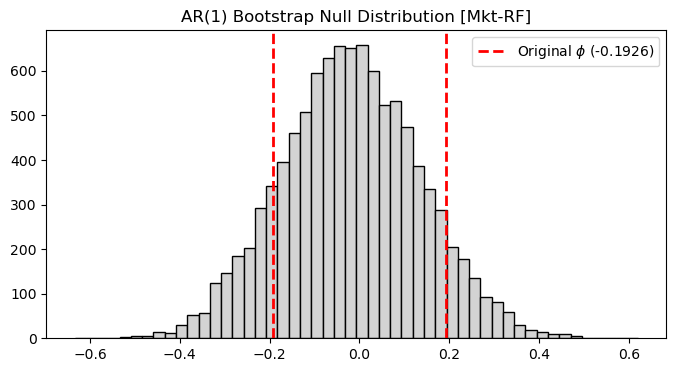


▶ 타겟 팩터: SMB
  - AR(1) 계수(phi): -0.1468
  - 일반 OLS P-value: 0.2436
  - HAC(Newey-West) P-value: 0.2725


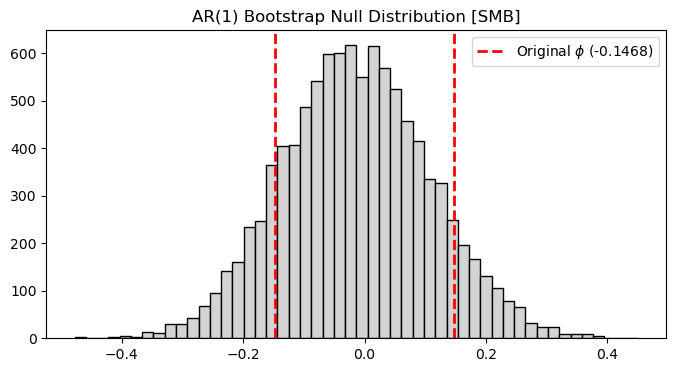


▶ 타겟 팩터: HML
  - AR(1) 계수(phi): 0.0761
  - 일반 OLS P-value: 0.5662
  - HAC(Newey-West) P-value: 0.4418


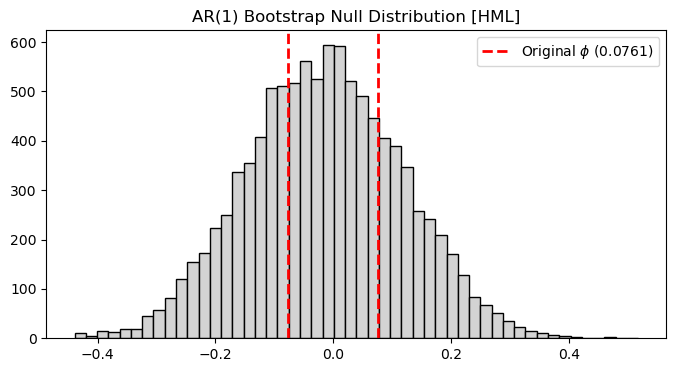


▶ 타겟 팩터: RMW
  - AR(1) 계수(phi): 0.1308
  - 일반 OLS P-value: 0.3136
  - HAC(Newey-West) P-value: 0.1992


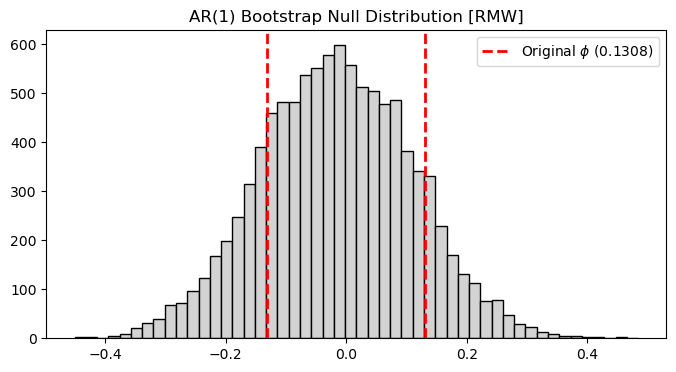


▶ 타겟 팩터: CMA
  - AR(1) 계수(phi): 0.1216
  - 일반 OLS P-value: 0.3482
  - HAC(Newey-West) P-value: 0.3707


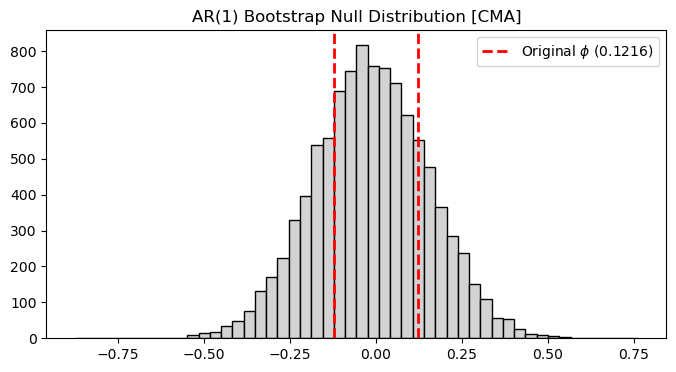


2. 다변량 VAR(1) 검정 (HAC 우회 적용) 및 부트스트랩

▶ [Mkt-RF -> Mkt-RF] 계수 검정 결과 비교
  - VAR 계수(Phi_11): -0.2829
  - 일반 P-value: 0.0387
  - HAC(Newey-West) P-value: 0.0178  *(방정식별 OLS 변환 사용)*


c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


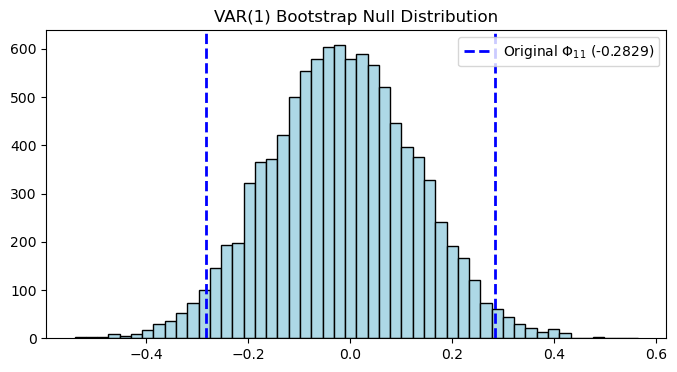

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from arch import arch_model
import matplotlib.pyplot as plt
import pandas_datareader.data as web

# =====================================================================
# 0. 데이터 준비 (강건성.ipynb 파일과 동일하게 파마-프렌치 5팩터 사용)
# =====================================================================
print("Fama-French 5 Factors 데이터를 준비합니다...")
ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2001-01-01", end="2025-12-31")[0].copy()
ff5.index = pd.to_datetime(ff5.index.astype(str)) + pd.offsets.MonthEnd(0)
ff5 = ff5 / 100.0
F = ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].dropna()

# 윈도우 사이즈 설정 (최근 60개월)
window_size = 60
y = F.iloc[-window_size:] 

# 데이터 길이 및 변수 개수
T = len(y)
K = y.shape[1] # 변수 개수 (5개)

iterations = 10000  # 부트스트랩 반복 횟수

# =====================================================================
# 1. 사용자님이 올려주신 원본 AR Bootstrap 함수 (factor_name 추가)
# =====================================================================
def bootstrap(garch_fit, resids, y, T, iterations, phi_hat, factor_name):
    boot_phis_null = []
    omega, alpha, beta = garch_fit.params['omega'], garch_fit.params['alpha[1]'], garch_fit.params['beta[1]']
    cond_vol = garch_fit.conditional_volatility
    std_resids = (resids / cond_vol).dropna().values
    
    model_h0 = sm.OLS(y, np.ones(T)).fit()
    c_h0 = model_h0.params.iloc[0]
    resids_h0 = model_h0.resid
    
    garch_h0 = arch_model(resids_h0, vol='Garch', p=1, q=1, rescale=False)
    garch_fit_h0 = garch_h0.fit(disp='off')
    omega_h0, alpha_h0, beta_h0 = garch_fit_h0.params['omega'], garch_fit_h0.params['alpha[1]'], garch_fit_h0.params['beta[1]']
    std_resids_h0 = (resids_h0 / garch_fit_h0.conditional_volatility).dropna().values
    
    for _ in range(iterations):
        sim_y = np.zeros(T)
        sim_sigma2 = np.zeros(T)
        sim_eps = np.zeros(T)       
        sim_sigma2[0] = np.var(resids_h0)
        sim_eps[0] = resids_h0.iloc[0]
        sim_y[0] = y.iloc[0]       
        random_z = np.random.choice(std_resids_h0, size=T, replace=True)
        for t in range(1, T):
            sim_sigma2[t] = omega_h0 + alpha_h0 * (sim_eps[t-1]**2) + beta_h0 * sim_sigma2[t-1]
            sim_eps[t] = np.sqrt(sim_sigma2[t]) * random_z[t]
            sim_y[t] = c_h0 + sim_eps[t]
            
        sim_X = sm.add_constant(pd.Series(sim_y).shift(1).dropna())
        sim_model = sm.OLS(sim_y[1:], sim_X).fit()
        boot_phis_null.append(sim_model.params.iloc[1])
        
    boot_phis_null = np.array(boot_phis_null)
    p_value = np.mean(np.abs(boot_phis_null) >= np.abs(phi_hat))
    
    fig = plt.figure(figsize=(8, 4))
    plt.hist(boot_phis_null, bins=50, color='lightgray', edgecolor='black')
    plt.axvline(phi_hat, color='red', linestyle='dashed', linewidth=2, label=f'Original $\phi$ ({phi_hat:.4f})')
    plt.axvline(-phi_hat, color='red', linestyle='dashed', linewidth=2)
    plt.title(f'AR(1) Bootstrap Null Distribution [{factor_name}]')
    plt.legend()
    plt.show()
    return boot_phis_null

# =====================================================================
# 2. VAR(1) Bootstrap 함수
# =====================================================================
def bootstrap_var(y, resids, T, K, iterations, phi_hat):
    c_h0 = y.mean(axis=0).values
    resids_h0 = (y - c_h0).values
    boot_phis_null = np.zeros((iterations, K, K))
    
    for i in range(iterations):
        sim_y = np.zeros((T, K))
        sim_y[0] = y.iloc[0].values
        
        # 5개 변수 잔차 묶음을 동시 리샘플링
        random_indices = np.random.choice(T, size=T, replace=True)
        sim_resids = resids_h0[random_indices]
        
        for t in range(1, T):
            sim_y[t] = c_h0 + sim_resids[t]
            
        sim_df = pd.DataFrame(sim_y, columns=y.columns)
        sim_model = VAR(sim_df)
        try:
            sim_results = sim_model.fit(1)
            boot_phis_null[i] = sim_results.coefs[0]
        except np.linalg.LinAlgError:
            continue
            
    # Mkt-RF가 Mkt-RF에 미치는 계수(5x5 행렬 중 [0,0])를 기준으로 시각화
    p_value = np.mean(np.abs(boot_phis_null[:, 0, 0]) >= np.abs(phi_hat[0, 0]))
    
    fig = plt.figure(figsize=(8, 4))
    plt.hist(boot_phis_null[:, 0, 0], bins=50, color='lightblue', edgecolor='black')
    plt.axvline(phi_hat[0, 0], color='blue', linestyle='dashed', linewidth=2, label=f'Original $\Phi_{{11}}$ ({phi_hat[0, 0]:.4f})')
    plt.axvline(-phi_hat[0, 0], color='blue', linestyle='dashed', linewidth=2)
    plt.title(f'VAR(1) Bootstrap Null Distribution')
    plt.legend()
    plt.show()
    return boot_phis_null

# =====================================================================
# 3. 실행 및 시각화 출력 (+ HAC 테스트)
# =====================================================================

print("\n========================================================")
print("1. 단변량 AR(1) 검정 (HAC) 및 부트스트랩")
print("========================================================")
ar_results = {}
for col in y.columns:
    print(f"\n▶ 타겟 팩터: {col}")
    y_ar = y[col]
    
    # 모델 피팅
    X_ar = sm.add_constant(y_ar.shift(1).dropna())
    
    # 1. 일반 OLS 결과
    model_ar_ols = sm.OLS(y_ar.iloc[1:], X_ar).fit()
    pval_ols = model_ar_ols.pvalues.iloc[1]
    
    # 2. HAC(Newey-West) 결과 (lag=1)
    model_ar_hac = sm.OLS(y_ar.iloc[1:], X_ar).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    pval_hac = model_ar_hac.pvalues.iloc[1]
    
    print(f"  - AR(1) 계수(phi): {model_ar_ols.params.iloc[1]:.4f}")
    print(f"  - 일반 OLS P-value: {pval_ols:.4f}")
    print(f"  - HAC(Newey-West) P-value: {pval_hac:.4f}")
    
    # 부트스트랩 진행
    c_hat_ar, phi_hat_ar = model_ar_ols.params.iloc[0], model_ar_ols.params.iloc[1]
    resids_ar = model_ar_ols.resid
    
    garch = arch_model(resids_ar, vol='Garch', p=1, q=1, rescale=False)
    garch_fit = garch.fit(disp='off')
    
    ar_results[col] = bootstrap(garch_fit, resids_ar, y_ar, T, iterations, phi_hat_ar, factor_name=col)


print("\n========================================================")
print("2. 다변량 VAR(1) 검정 (HAC 우회 적용) 및 부트스트랩")
print("========================================================")

# 1. 원본 VAR 피팅
model_var = VAR(y)
var_fit = model_var.fit(1)
phi_hat_var = var_fit.coefs[0]
resids_var = var_fit.resid

print("\n▶ [Mkt-RF -> Mkt-RF] 계수 검정 결과 비교")
# statsmodels VAR의 기본 (일반) p-value
var_pval_mkt = var_fit.pvalues['Mkt-RF'].loc['L1.Mkt-RF']

print(f"  - VAR 계수(Phi_11): {phi_hat_var[0, 0]:.4f}")
print(f"  - 일반 P-value: {var_pval_mkt:.4f}")

# -------------------------------------------------------------
# [VAR 방정식별 HAC 적용 로직 추가]
# 스택오버플로우 조언에 따라 VAR을 개별 OLS 방정식으로 분해하여 HAC를 적용합니다.
# -------------------------------------------------------------
# 설명변수(X): 5개 팩터 모두의 과거 1시점(t-1) 데이터 + 상수항
X_var_hac = sm.add_constant(y.shift(1).dropna())
# 반응변수(Y): 5개 팩터의 현재(t) 데이터
y_var_hac = y.iloc[1:]

# 우리는 [Mkt-RF -> Mkt-RF] 결과를 보기 위해 타겟을 'Mkt-RF'로 설정합니다.
var_eq_mkt = sm.OLS(y_var_hac['Mkt-RF'], X_var_hac).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

# X_var_hac 데이터프레임 안에서 'Mkt-RF' 컬럼(과거 시점)이 현재 'Mkt-RF'에 미치는 영향의 p-value를 가져옵니다.
hac_pval_mkt = var_eq_mkt.pvalues['Mkt-RF']

print(f"  - HAC(Newey-West) P-value: {hac_pval_mkt:.4f}  *(방정식별 OLS 변환 사용)*")

# 부트스트랩 실행
var_result = bootstrap_var(y, resids_var, T, K, iterations, phi_hat_var)

<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\P'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_23312\3451944828.py:65: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(phi_hat, color='red', linestyle='dashed', linewidth=2, label=f'Original $\phi$ ({phi_hat:.4f})')
C:\Users\USER\AppData\Local\Temp\ipykernel_23312\3451944828.py:104: SyntaxWarning: invalid escape sequence '\P'
  plt.axvline(phi_hat[0, 0], color='blue', linestyle='dashed', linewidth=2, label=f'Original $\Phi_{{11}}$ ({phi_hat[0, 0]:.4f})')


Fama-French 5 Factors 데이터를 준비합니다...


C:\Users\USER\AppData\Local\Temp\ipykernel_23312\3451944828.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2001-01-01", end="2025-12-31")[0].copy()
C:\Users\USER\AppData\Local\Temp\ipykernel_23312\3451944828.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2001-01-01", end="2025-12-31")[0].copy()



1. 단변량 AR(1) 검정 (HAC) 및 부트스트랩

▶ 타겟 팩터: Mkt-RF


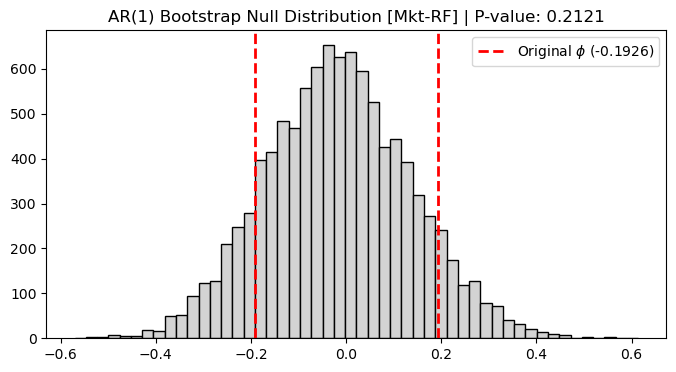

  [기존 모형 결과]
  - AR(1) 원본 계수(phi) : -0.1926
  - OLS P-value (SE)     : 0.1439 (0.1300)
  - HAC P-value (SE)     : 0.1026 (0.1180)
  [부트스트랩 강건성 결과 (반복: 10000회)]
  - 부트스트랩 P-value   : 0.2121
  - 부트스트랩 SE        : 0.1530
  - 부트스트랩 t-통계량  : -1.2590
  - 95% 임계값(기각역)   : [-0.3108, 0.2889]

▶ 타겟 팩터: SMB


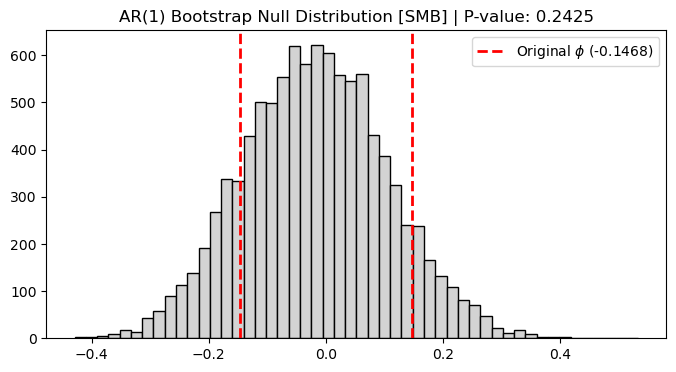

  [기존 모형 결과]
  - AR(1) 원본 계수(phi) : -0.1468
  - OLS P-value (SE)     : 0.2436 (0.1246)
  - HAC P-value (SE)     : 0.2725 (0.1338)
  [부트스트랩 강건성 결과 (반복: 10000회)]
  - 부트스트랩 P-value   : 0.2425
  - 부트스트랩 SE        : 0.1229
  - 부트스트랩 t-통계량  : -1.1951
  - 95% 임계값(기각역)   : [-0.2528, 0.2294]

▶ 타겟 팩터: HML


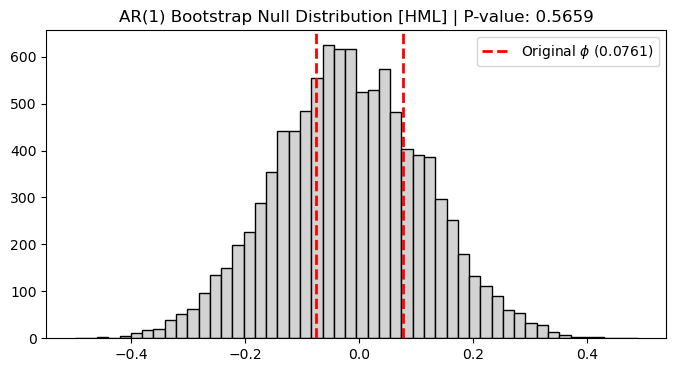

  [기존 모형 결과]
  - AR(1) 원본 계수(phi) : 0.0761
  - OLS P-value (SE)     : 0.5662 (0.1318)
  - HAC P-value (SE)     : 0.4418 (0.0989)
  [부트스트랩 강건성 결과 (반복: 10000회)]
  - 부트스트랩 P-value   : 0.5659
  - 부트스트랩 SE        : 0.1311
  - 부트스트랩 t-통계량  : 0.5802
  - 95% 임계값(기각역)   : [-0.2743, 0.2407]

▶ 타겟 팩터: RMW


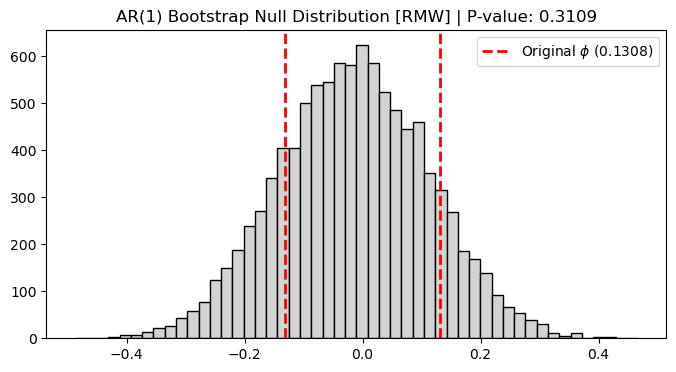

  [기존 모형 결과]
  - AR(1) 원본 계수(phi) : 0.1308
  - OLS P-value (SE)     : 0.3136 (0.1286)
  - HAC P-value (SE)     : 0.1992 (0.1019)
  [부트스트랩 강건성 결과 (반복: 10000회)]
  - 부트스트랩 P-value   : 0.3109
  - 부트스트랩 SE        : 0.1269
  - 부트스트랩 t-통계량  : 1.0305
  - 95% 임계값(기각역)   : [-0.2610, 0.2332]

▶ 타겟 팩터: CMA


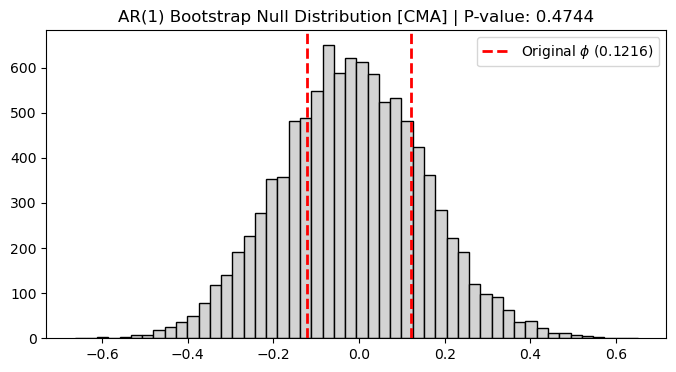

  [기존 모형 결과]
  - AR(1) 원본 계수(phi) : 0.1216
  - OLS P-value (SE)     : 0.3482 (0.1285)
  - HAC P-value (SE)     : 0.3707 (0.1358)
  [부트스트랩 강건성 결과 (반복: 10000회)]
  - 부트스트랩 P-value   : 0.4744
  - 부트스트랩 SE        : 0.1687
  - 부트스트랩 t-통계량  : 0.7205
  - 95% 임계값(기각역)   : [-0.3444, 0.3197]

2. 다변량 VAR(1) 검정 및 부트스트랩 [Mkt-RF -> Mkt-RF]


c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


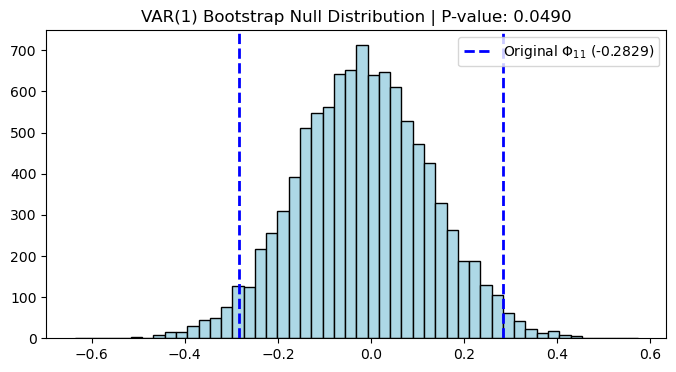

  [기존 모형 결과]
  - VAR 원본 계수(Phi_11): -0.2829
  - 일반 P-value (SE)    : 0.0387 (0.1368)
  - HAC P-value (SE)     : 0.0178 (0.1194)
  [부트스트랩 강건성 결과 (반복: 10000회)]
  - 부트스트랩 P-value   : 0.0490
  - 부트스트랩 SE        : 0.1429
  - 부트스트랩 t-통계량  : -1.9791
  - 95% 임계값(기각역)   : [-0.2964, 0.2633]


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from arch import arch_model
import matplotlib.pyplot as plt
import pandas_datareader.data as web

# =====================================================================
# 0. 데이터 준비
# =====================================================================
print("Fama-French 5 Factors 데이터를 준비합니다...")
ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2001-01-01", end="2025-12-31")[0].copy()
ff5.index = pd.to_datetime(ff5.index.astype(str)) + pd.offsets.MonthEnd(0)
ff5 = ff5 / 100.0
F = ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].dropna()

window_size = 60
y = F.iloc[-window_size:] 

T = len(y)
K = y.shape[1]
iterations = 10000

# =====================================================================
# 1. 단변량 AR(1) Bootstrap 함수
# =====================================================================
def bootstrap(garch_fit, resids, y, T, iterations, phi_hat, factor_name):
    boot_phis_null = []
    omega, alpha, beta = garch_fit.params['omega'], garch_fit.params['alpha[1]'], garch_fit.params['beta[1]']
    cond_vol = garch_fit.conditional_volatility
    std_resids = (resids / cond_vol).dropna().values
    
    model_h0 = sm.OLS(y, np.ones(T)).fit()
    c_h0 = model_h0.params.iloc[0]
    resids_h0 = model_h0.resid
    
    garch_h0 = arch_model(resids_h0, vol='Garch', p=1, q=1, rescale=False)
    garch_fit_h0 = garch_h0.fit(disp='off')
    omega_h0, alpha_h0, beta_h0 = garch_fit_h0.params['omega'], garch_fit_h0.params['alpha[1]'], garch_fit_h0.params['beta[1]']
    std_resids_h0 = (resids_h0 / garch_fit_h0.conditional_volatility).dropna().values
    
    for _ in range(iterations):
        sim_y = np.zeros(T)
        sim_sigma2 = np.zeros(T)
        sim_eps = np.zeros(T)       
        sim_sigma2[0] = np.var(resids_h0)
        sim_eps[0] = resids_h0.iloc[0]
        sim_y[0] = y.iloc[0]       
        random_z = np.random.choice(std_resids_h0, size=T, replace=True)
        for t in range(1, T):
            sim_sigma2[t] = omega_h0 + alpha_h0 * (sim_eps[t-1]**2) + beta_h0 * sim_sigma2[t-1]
            sim_eps[t] = np.sqrt(sim_sigma2[t]) * random_z[t]
            sim_y[t] = c_h0 + sim_eps[t]
            
        sim_X = sm.add_constant(pd.Series(sim_y).shift(1).dropna())
        sim_model = sm.OLS(sim_y[1:], sim_X).fit()
        boot_phis_null.append(sim_model.params.iloc[1])
        
    boot_phis_null = np.array(boot_phis_null)
    boot_pval = np.mean(np.abs(boot_phis_null) >= np.abs(phi_hat))
    
    fig = plt.figure(figsize=(8, 4))
    plt.hist(boot_phis_null, bins=50, color='lightgray', edgecolor='black')
    plt.axvline(phi_hat, color='red', linestyle='dashed', linewidth=2, label=f'Original $\phi$ ({phi_hat:.4f})')
    plt.axvline(-phi_hat, color='red', linestyle='dashed', linewidth=2)
    plt.title(f'AR(1) Bootstrap Null Distribution [{factor_name}] | P-value: {boot_pval:.4f}')
    plt.legend()
    plt.show()
    
    return boot_phis_null, boot_pval

# =====================================================================
# 2. 다변량 VAR(1) Bootstrap 함수
# =====================================================================
# =====================================================================
# 2. 다변량 VAR(1) Wild Bootstrap 함수 (수정됨)
# =====================================================================
def bootstrap_var(y, resids, T, K, iterations, phi_hat):
    c_h0 = y.mean(axis=0).values
    resids_h0 = (y - c_h0).values
    boot_phis_null = np.zeros((iterations, K, K))
    
    for i in range(iterations):
        sim_y = np.zeros((T, K))
        sim_y[0] = y.iloc[0].values
        
        # ---------------------------------------------------------
        # [핵심 수정] Wild Bootstrap 적용 (논문 방식)
        # 1. 정규분포 N(0,1) 난수 생성 (Rademacher 분포인 [-1, 1]을 써도 좋습니다)
        # 2. size=(T, 1)로 설정하여, 같은 시점(t)의 모든 팩터(K)에 동일한 부호를 곱해줍니다.
        #    (이래야 팩터 간의 동시적 상관관계(Cross-correlation)가 파괴되지 않습니다.)
        # ---------------------------------------------------------
        multipliers = np.random.normal(loc=0.0, scale=1.0, size=(T, 1))
        # multipliers = np.random.choice([-1, 1], size=(T, 1)) # 대안: Rademacher 분포
        
        # 원래 잔차를 무작위로 섞지 않고, 제자리에서 난수만 곱해 이분산성을 보존합니다.
        sim_resids = resids_h0 * multipliers
        
        for t in range(1, T):
            sim_y[t] = c_h0 + sim_resids[t]
            
        sim_df = pd.DataFrame(sim_y, columns=y.columns)
        sim_model = VAR(sim_df)
        try:
            sim_results = sim_model.fit(1)
            boot_phis_null[i] = sim_results.coefs[0]
        except np.linalg.LinAlgError:
            continue
            
    boot_dist_mkt = boot_phis_null[:, 0, 0]
    boot_pval = np.mean(np.abs(boot_dist_mkt) >= np.abs(phi_hat[0, 0]))
    
    fig = plt.figure(figsize=(8, 4))
    plt.hist(boot_dist_mkt, bins=50, color='lightblue', edgecolor='black')
    plt.axvline(phi_hat[0, 0], color='blue', linestyle='dashed', linewidth=2, label=f'Original $\Phi_{{11}}$ ({phi_hat[0, 0]:.4f})')
    plt.axvline(-phi_hat[0, 0], color='blue', linestyle='dashed', linewidth=2)
    plt.title(f'VAR(1) Wild Bootstrap Null Distribution | P-value: {boot_pval:.4f}')
    plt.legend()
    plt.show()
    
    return boot_phis_null, boot_pval

# =====================================================================
# 3. 실행 및 시각화/통계량 출력
# =====================================================================

print("\n========================================================")
print("1. 단변량 AR(1) 검정 (HAC) 및 부트스트랩")
print("========================================================")
ar_results = {}
for col in y.columns:
    print(f"\n▶ 타겟 팩터: {col}")
    y_ar = y[col]
    X_ar = sm.add_constant(y_ar.shift(1).dropna())
    
    model_ar_ols = sm.OLS(y_ar.iloc[1:], X_ar).fit()
    pval_ols = model_ar_ols.pvalues.iloc[1]
    ols_se = model_ar_ols.bse.iloc[1]
    
    model_ar_hac = sm.OLS(y_ar.iloc[1:], X_ar).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    pval_hac = model_ar_hac.pvalues.iloc[1]
    hac_se = model_ar_hac.bse.iloc[1]
    
    phi_hat_ar = model_ar_ols.params.iloc[1]
    resids_ar = model_ar_ols.resid
    
    garch = arch_model(resids_ar, vol='Garch', p=1, q=1, rescale=False)
    garch_fit = garch.fit(disp='off')
    
    # 부트스트랩 실행 및 통계량 도출
    boot_dist, boot_pval = bootstrap(garch_fit, resids_ar, y_ar, T, iterations, phi_hat_ar, factor_name=col)
    
    boot_se = np.std(boot_dist, ddof=1)
    boot_t_stat = phi_hat_ar / boot_se
    crit_lower, crit_upper = np.percentile(boot_dist, [2.5, 97.5])
    
    print(f"  [기존 모형 결과]")
    print(f"  - AR(1) 원본 계수(phi) : {phi_hat_ar:.4f}")
    print(f"  - OLS P-value (SE)     : {pval_ols:.4f} ({ols_se:.4f})")
    print(f"  - HAC P-value (SE)     : {pval_hac:.4f} ({hac_se:.4f})")
    print(f"  [부트스트랩 강건성 결과 (반복: {iterations}회)]")
    print(f"  - 부트스트랩 P-value   : {boot_pval:.4f}")
    print(f"  - 부트스트랩 SE        : {boot_se:.4f}")
    print(f"  - 부트스트랩 t-통계량  : {boot_t_stat:.4f}")
    print(f"  - 95% 임계값(기각역)   : [{crit_lower:.4f}, {crit_upper:.4f}]")


print("\n========================================================")
print("2. 다변량 VAR(1) 검정 및 부트스트랩 [Mkt-RF -> Mkt-RF]")
print("========================================================")

model_var = VAR(y)
var_fit = model_var.fit(1)
phi_hat_var = var_fit.coefs[0]
resids_var = var_fit.resid

var_pval_mkt = var_fit.pvalues['Mkt-RF'].loc['L1.Mkt-RF']
var_se_mkt = var_fit.stderr['Mkt-RF'].loc['L1.Mkt-RF']

X_var_hac = sm.add_constant(y.shift(1).dropna())
y_var_hac = y.iloc[1:]
var_eq_mkt = sm.OLS(y_var_hac['Mkt-RF'], X_var_hac).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
hac_pval_mkt = var_eq_mkt.pvalues['Mkt-RF']
hac_se_mkt = var_eq_mkt.bse['Mkt-RF']

# 부트스트랩 실행
boot_phis_var, boot_pval_var = bootstrap_var(y, resids_var, T, K, iterations, phi_hat_var)

# 통계량 추출 (Mkt-RF -> Mkt-RF 계수에 대해서만)
boot_dist_var_mkt = boot_phis_var[:, 0, 0]
original_coef_var = phi_hat_var[0, 0]

boot_se_var = np.std(boot_dist_var_mkt, ddof=1)
boot_t_stat_var = original_coef_var / boot_se_var
crit_lower_var, crit_upper_var = np.percentile(boot_dist_var_mkt, [2.5, 97.5])

print(f"  [기존 모형 결과]")
print(f"  - VAR 원본 계수(Phi_11): {original_coef_var:.4f}")
print(f"  - 일반 P-value (SE)    : {var_pval_mkt:.4f} ({var_se_mkt:.4f})")
print(f"  - HAC P-value (SE)     : {hac_pval_mkt:.4f} ({hac_se_mkt:.4f})")
print(f"  [부트스트랩 강건성 결과 (반복: {iterations}회)]")
print(f"  - 부트스트랩 P-value   : {boot_pval_var:.4f}")
print(f"  - 부트스트랩 SE        : {boot_se_var:.4f}")
print(f"  - 부트스트랩 t-통계량  : {boot_t_stat_var:.4f}")
print(f"  - 95% 임계값(기각역)   : [{crit_lower_var:.4f}, {crit_upper_var:.4f}]")